# Benchmark Thesis Walkthrough

This notebook rebuilds the thesis figures from the **correct data source for each figure**.

Important: Figures 2–9 use the 100k benchmark sample (92,160 transactions after filtering). Figures 10–12 use the full catalogue / held-out industrial evaluation outputs. They should not all be generated from the same preview sample.

## Figure Data Sources

| Figure | Correct source |
|---|---|
| 2–9 | `Bachelor_final/benchmark_results/memory_100k/benchmark_summary.csv` and `phase_breakdown.csv` (100k sample; 92,160 filtered transactions) |
| 10 | Full catalogue inventory, 476,455 categorized products |
| 11 | Full catalogue candidate-space reduction. The thesis PNG was generated from `rule_candidate_space_reduction.csv` with 232 rules; the text also mentions a 330-rule held-out-train variant. |
| 12 | 100k sample split 80k train / 20k test; candidate masks evaluated against the full catalogue |

For the runtime-by-K figure, this notebook uses the runtime values stated in the thesis text/table so the `K=1` relation is correct: Python Cumulate is faster than mlxtend at `K=1`.

## Output Review

Current status after checking the embedded outputs:

| Figure | Status | Note |
|---|---|---|
| 2 | Correct data and counts | Uses 100k sample; final totals are 2, 256, 1901, 2977, 3062. |
| 3 | Correct data and counts | Uses 100k sample; mlxtend flat is 2 for every K. |
| 4 | Corrected | Uses the thesis runtime table values, so Python is faster than mlxtend at K=1: 0.770s vs 1.345s. If you still see Python slower, reload the notebook because that is stale output. |
| 5 | Mostly correct | Uses thesis support table for Python time/final rules; raw-rule line comes from the old 100k benchmark summary. |
| 6 | Generated from K-sweep summary | Reads only `runtime_k` rows; support-sweep rows are excluded, `mlxtend_flat` is collapsed to one median point, and the cell warns if the source CSV has the wrong Python-vs-mlxtend K=1 relation. |
| 7 | Correct counts, style not exact | Raw=3411, score=3405, family=3405, final=1901. Typography/layout is larger than the thesis PDF rendering. |
| 8 | Correct counts, style not exact | Uses 100k K-sweep redundancy counts. Typography/layout can be tightened to match the thesis image. |
| 9 | Correct source family, style/source details still uncertain | Uses 100k phase breakdown CSV. The thesis text discusses the K=3 Python wall-clock breakdown, while the plotted figure shows all K/implementation bars. |
| 10 | Exact thesis source | Copied from full catalogue industrial output; 476,455 categorized products. |
| 11 | Exact thesis source, but text mismatch exists | Copied from source PNG. The PNG is from 232 rules; thesis discussion mentions the 330-rule held-out-train variant. Median is the same, but text/figure source should be made consistent. |
| 12 | Exact thesis source | Copied from held-out industrial evaluation; 80k/20k split on the 100k sample. |

Next fixes should be: make Figures 7–9 visually match the thesis PNGs more closely, and decide whether Figure 11 should use the 232-rule or 330-rule candidate-space table.


In [2]:

from pathlib import Path
import shutil

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent

BACHELOR = Path(r'C:\Users\awchr\OneDrive\Dokumenter\GitHub\Bachelor_final')
MEMORY_100K = BACHELOR / 'benchmark_results' / 'memory_100k'
INDUSTRIAL = BACHELOR / 'outputs' / 'full_dataset_benchmark_clean' / 'industrial_candidate_benchmark_category_only'
THESIS_ZIP = Path(r'C:\Users\awchr\OneDrive\Dokumenter\GitHub\Bachelor_final\GoWish___Thesis (4).zip')
OUT = REPO_ROOT / 'results' / 'thesis_rebuilt_figures'
REFERENCE = OUT / 'reference'
OUT.mkdir(parents=True, exist_ok=True)
REFERENCE.mkdir(parents=True, exist_ok=True)

summary = pd.read_csv(MEMORY_100K / 'benchmark_summary.csv')
phase = pd.read_csv(MEMORY_100K / 'phase_breakdown.csv')

plt.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.dpi': 160,
})

COL_PY = '#56B4E9'
COL_CPP = '#009E73'
COL_MLX = '#D55E00'
COL_RED = '#E15759'
COL_ORANGE = '#F5A623'
COL_PURPLE = '#6A5ACD'

def paper_axes(ax):
    ax.tick_params(direction='in', top=True, right=True, width=0.8)
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)


def save_show(fig, name):
    path = OUT / name
    fig.tight_layout()
    fig.savefig(path, dpi=220, bbox_inches='tight')
    plt.close(fig)
    display(Image(filename=str(path)))
    print(path)
    return path



def extract_thesis_figure(name):
    target = REFERENCE / name
    if not target.exists() and THESIS_ZIP.exists():
        import zipfile
        with zipfile.ZipFile(THESIS_ZIP) as z:
            with z.open(f'figures/{name}') as source, target.open('wb') as dest:
                shutil.copyfileobj(source, dest)
    return target

def show_existing(src, dst_name=None):
    src = Path(src)
    dst = OUT / (dst_name or src.name)
    shutil.copy2(src, dst)
    display(Image(filename=str(dst)))
    print(dst)
    return dst

print('100k summary:', MEMORY_100K / 'benchmark_summary.csv')
print('industrial:', INDUSTRIAL)
print('output:', OUT)


SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 2-3: truncated \UXXXXXXXX escape (1326329649.py, line 13)

## Figure 2

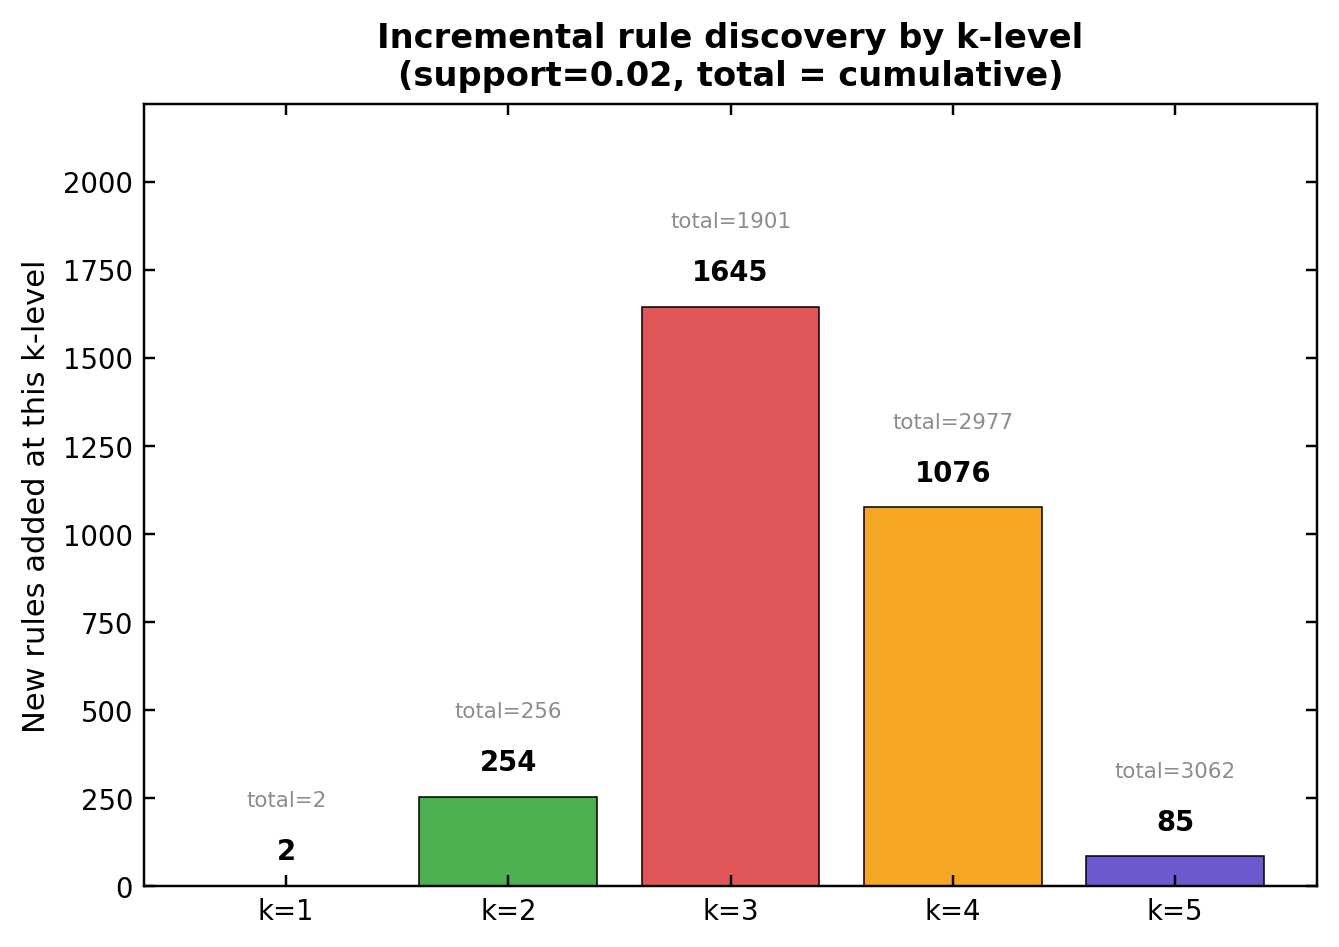

/Users/kevinkinsella/Documents/GitHub/In-Memory-Association-Rule-Mining-with-Hierarchical-Taxonomies/results/thesis_rebuilt_figures/fig02_thesis_incremental_k.png


PosixPath('/Users/kevinkinsella/Documents/GitHub/In-Memory-Association-Rule-Mining-with-Hierarchical-Taxonomies/results/thesis_rebuilt_figures/fig02_thesis_incremental_k.png')

In [2]:

# Figure 2: Incremental rule discovery by K, 100k sample
cum = summary[(summary.experiment == 'runtime_k') & (summary.implementation == 'python_cumulate')].copy()
cum = cum.sort_values('k_levels')
ks = cum['k_levels'].astype(int).tolist()
finals = cum['final_rules_median'].astype(int).tolist()
incremental = [finals[0]] + [finals[i] - finals[i-1] for i in range(1, len(finals))]
colors = ['#4C78A8', '#4CAF50', COL_RED, COL_ORANGE, COL_PURPLE]

fig, ax = plt.subplots(figsize=(6.2, 4.4))
bars = ax.bar(range(len(ks)), incremental, color=colors, edgecolor='black', linewidth=0.5)
ymax = max(incremental)
ax.set_ylim(0, ymax * 1.35)
for i, (bar, inc, total) in enumerate(zip(bars, incremental, finals)):
    x = bar.get_x() + bar.get_width() / 2
    ax.text(x, inc + ymax * 0.035, f'{inc}', ha='center', va='bottom', fontweight='bold', fontsize=9)
    ax.text(x, inc + ymax * 0.13, f'total={total}', ha='center', va='bottom', color='0.55', fontsize=7)
ax.set_xticks(range(len(ks)), [f'k={k}' for k in ks])
ax.set_ylabel('New rules added at this k-level')
ax.set_title('Incremental rule discovery by k-level\n(support=0.02, total = cumulative)', fontweight='bold')
paper_axes(ax)
save_show(fig, 'fig02_thesis_incremental_k.png')


## Figure 3

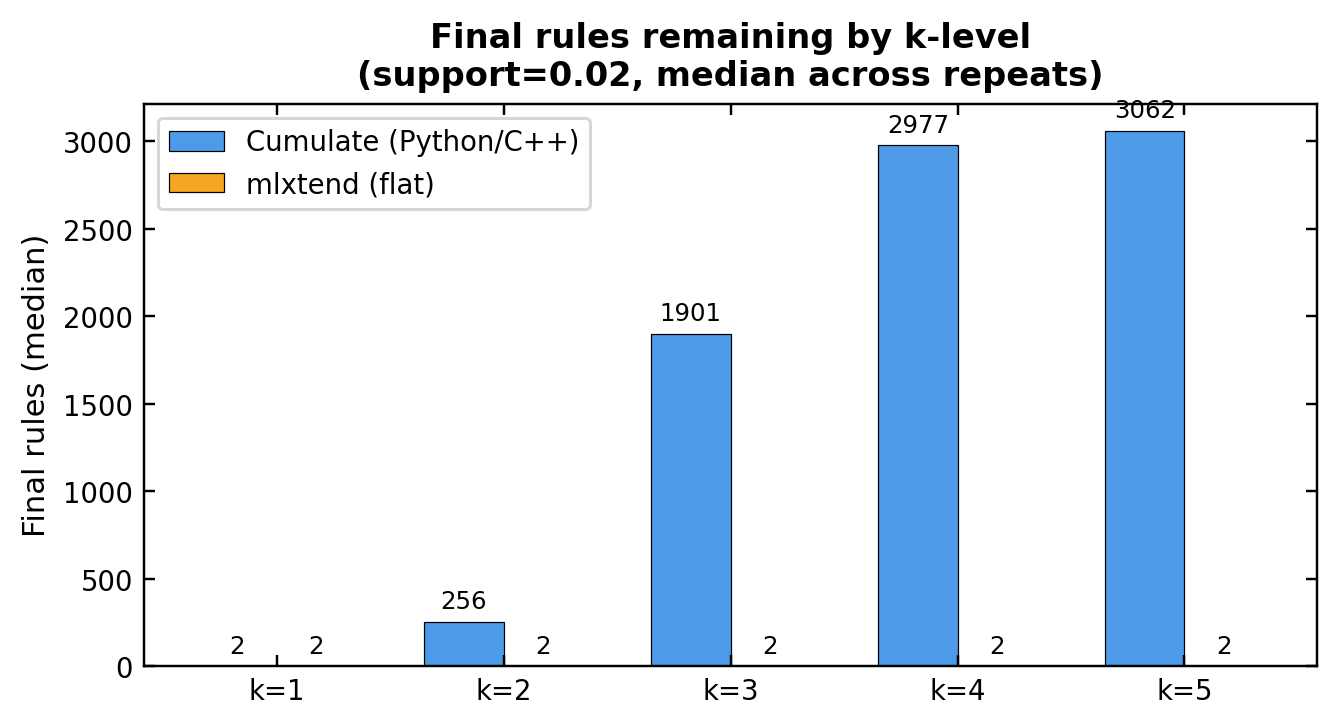

/Users/kevinkinsella/Documents/GitHub/In-Memory-Association-Rule-Mining-with-Hierarchical-Taxonomies/results/thesis_rebuilt_figures/fig03_final_rules_cumulate_vs_mlxtend_by_k.png


PosixPath('/Users/kevinkinsella/Documents/GitHub/In-Memory-Association-Rule-Mining-with-Hierarchical-Taxonomies/results/thesis_rebuilt_figures/fig03_final_rules_cumulate_vs_mlxtend_by_k.png')

In [3]:

# Figure 3: Cumulate vs mlxtend by K, 100k sample
mlx = summary[(summary.experiment == 'runtime_k') & (summary.implementation == 'mlxtend_flat')].sort_values('k_levels')
mlx_rules = mlx['final_rules_median'].fillna(0).astype(int).tolist()

fig, ax = plt.subplots(figsize=(6.2, 3.4))
x = np.arange(len(ks)); w = 0.35
b1 = ax.bar(x - w/2, finals, width=w, color='#4C9AE8', edgecolor='black', linewidth=0.4, label='Cumulate (Python/C++)')
b2 = ax.bar(x + w/2, mlx_rules, width=w, color=COL_ORANGE, edgecolor='black', linewidth=0.4, label='mlxtend (flat)')
for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + max(finals)*0.015, f'{int(h)}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x, [f'k={k}' for k in ks])
ax.set_ylabel('Final rules (median)')
ax.set_title('Final rules remaining by k-level\n(support=0.02, median across repeats)', fontweight='bold')
ax.legend(loc='upper left', frameon=True)
paper_axes(ax)
save_show(fig, 'fig03_final_rules_cumulate_vs_mlxtend_by_k.png')


## Figure 4

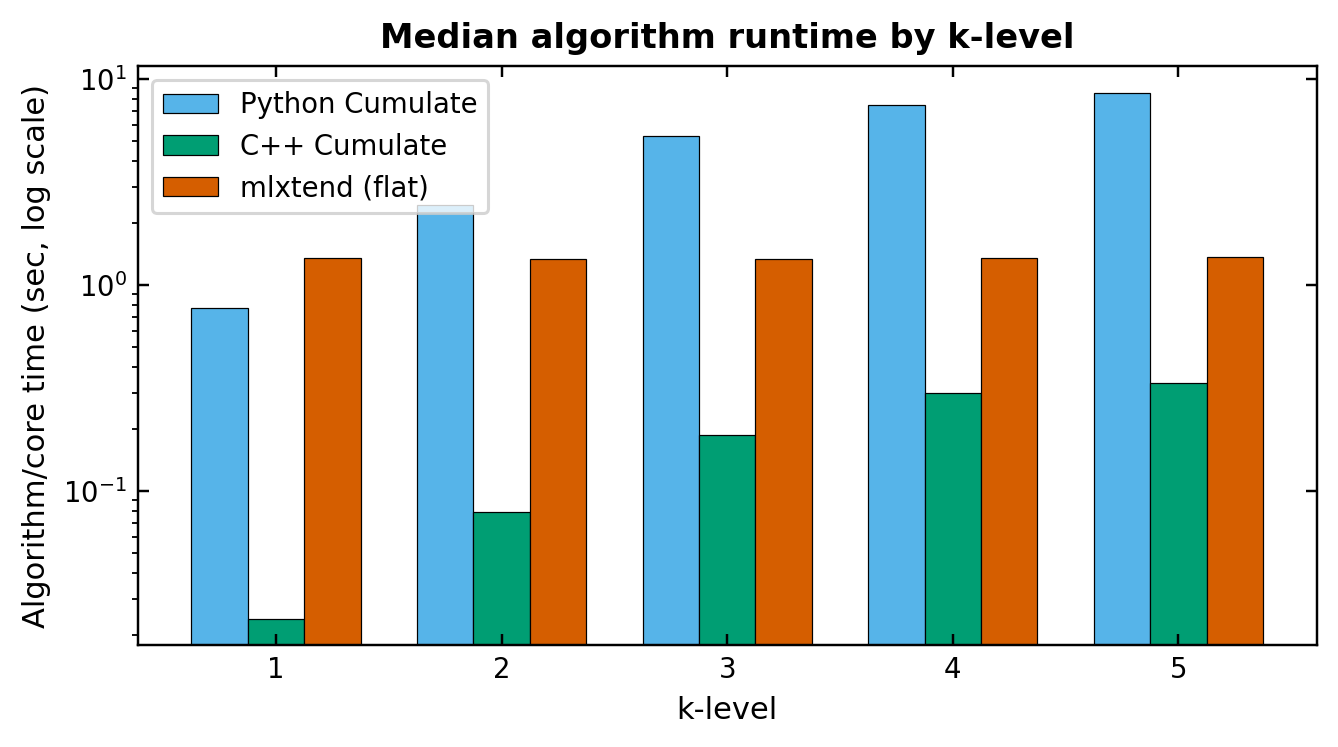

/Users/kevinkinsella/Documents/GitHub/In-Memory-Association-Rule-Mining-with-Hierarchical-Taxonomies/results/thesis_rebuilt_figures/fig04_runtime_by_k_level_python_cpp.png


PosixPath('/Users/kevinkinsella/Documents/GitHub/In-Memory-Association-Rule-Mining-with-Hierarchical-Taxonomies/results/thesis_rebuilt_figures/fig04_runtime_by_k_level_python_cpp.png')

In [4]:

# Figure 4: Runtime by K.
# These are the values reported in the thesis runtime table.
runtime_k = pd.DataFrame({
    'k': [1, 2, 3, 4, 5],
    'python_cumulate': [0.770, 2.429, 5.261, 7.427, 8.582],
    'cpp_cumulate': [0.024, 0.079, 0.187, 0.299, 0.336],
    'mlxtend_flat': [1.345, 1.340, 1.342, 1.357, 1.365],
})
fig, ax = plt.subplots(figsize=(6.2, 3.5))
x = np.arange(len(runtime_k)); w = 0.25
ax.bar(x - w, runtime_k['python_cumulate'], width=w, color=COL_PY, edgecolor='black', linewidth=0.4, label='Python Cumulate')
ax.bar(x, runtime_k['cpp_cumulate'], width=w, color=COL_CPP, edgecolor='black', linewidth=0.4, label='C++ Cumulate')
ax.bar(x + w, runtime_k['mlxtend_flat'], width=w, color=COL_MLX, edgecolor='black', linewidth=0.4, label='mlxtend (flat)')
ax.set_yscale('log')
ax.set_xticks(x, runtime_k['k'])
ax.set_xlabel('k-level')
ax.set_ylabel('Algorithm/core time (sec, log scale)')
ax.set_title('Median algorithm runtime by k-level', fontweight='bold')
ax.legend(loc='upper left', frameon=True)
paper_axes(ax)
save_show(fig, 'fig04_runtime_by_k_level_python_cpp.png')


## Figure 5

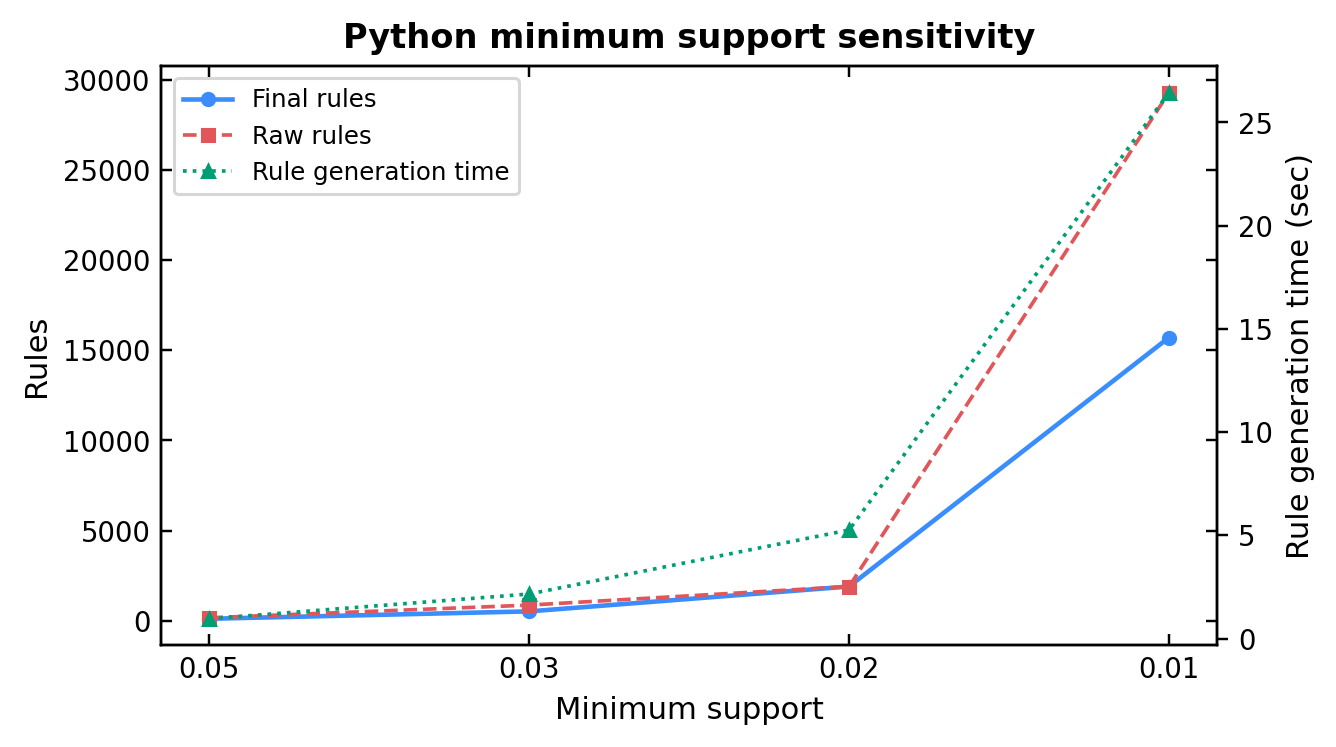

/Users/kevinkinsella/Documents/GitHub/In-Memory-Association-Rule-Mining-with-Hierarchical-Taxonomies/results/thesis_rebuilt_figures/fig05_python_support_sensitivity.png


PosixPath('/Users/kevinkinsella/Documents/GitHub/In-Memory-Association-Rule-Mining-with-Hierarchical-Taxonomies/results/thesis_rebuilt_figures/fig05_python_support_sensitivity.png')

In [5]:

# Figure 5: Support sensitivity, 100k sample, K=3.
support_df = pd.DataFrame({
    'support': [0.05, 0.03, 0.02, 0.01],
    'time': [0.96, 2.16, 5.261, 26.45],
    'final_rules': [112, 522, 1901, 15704],
})
# Raw rule counts from old benchmark summary when available.
raw_map = summary[(summary.experiment == 'support_sweep') & (summary.implementation == 'python_cumulate')].set_index('min_support')['raw_rules_median'].to_dict()
support_df['raw_rules'] = support_df['support'].map(raw_map).fillna(support_df['final_rules'])

fig, ax1 = plt.subplots(figsize=(6.2, 3.5))
x = np.arange(len(support_df))
ax1.plot(x, support_df['final_rules'], marker='o', color='#3A8DFF', linewidth=1.5, markersize=4, label='Final rules')
ax1.plot(x, support_df['raw_rules'], marker='s', linestyle='--', color=COL_RED, linewidth=1.2, markersize=4, label='Raw rules')
ax1.set_xticks(x, [f'{s:g}' for s in support_df['support']])
ax1.set_xlabel('Minimum support')
ax1.set_ylabel('Rules')
ax2 = ax1.twinx()
ax2.plot(x, support_df['time'], marker='^', linestyle=':', color=COL_CPP, linewidth=1.2, markersize=4, label='Rule generation time')
ax2.set_ylabel('Rule generation time (sec)')
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left', frameon=True, fontsize=8)
ax1.set_title('Python minimum support sensitivity', fontweight='bold')
paper_axes(ax1)
save_show(fig, 'fig05_python_support_sensitivity.png')


## Figure 6

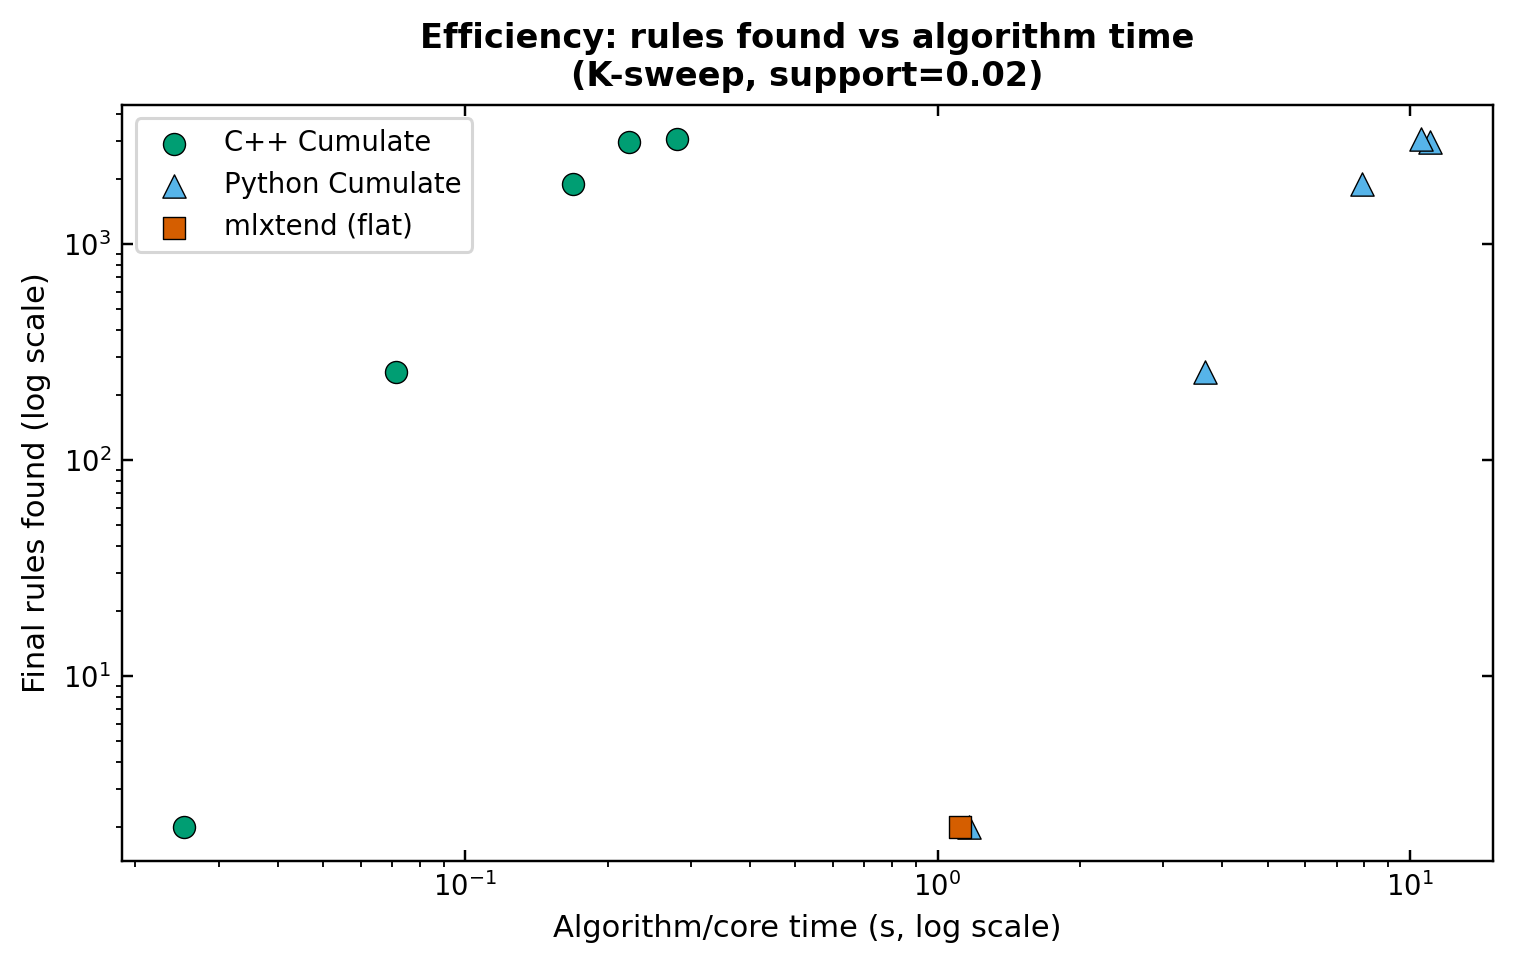

/Users/kevinkinsella/Documents/GitHub/In-Memory-Association-Rule-Mining-with-Hierarchical-Taxonomies/results/thesis_rebuilt_figures/fig06_thesis_efficiency_scatter.png
Figure 6 data source: /Users/kevinkinsella/Documents/GitHub/Bachelor_final/benchmark_results/memory_100k/benchmark_summary.csv
Figure 6 filter: experiment == runtime_k, implementations == cpp/python Cumulate + mlxtend_flat


,experiment,implementation,k_levels,min_support,algorithm_core_seconds_median,final_rules_median
0,runtime_k,cpp_cumulate,1,0.02,0.025373,2.0
1,runtime_k,cpp_cumulate,2,0.02,0.071208,256.0
2,runtime_k,cpp_cumulate,3,0.02,0.169044,1901.0
3,runtime_k,cpp_cumulate,4,0.02,0.222253,2977.0
4,runtime_k,cpp_cumulate,5,0.02,0.280248,3062.0
5,runtime_k,mlxtend_flat,all,0.02,1.115000,2.0
6,runtime_k,python_cumulate,1,0.02,1.165000,2.0
7,runtime_k,python_cumulate,2,0.02,3.680000,256.0
8,runtime_k,python_cumulate,3,0.02,7.937000,1901.0
9,runtime_k,python_cumulate,4,0.02,11.068000,2977.0


In [6]:
# Figure 6: Efficiency scatter generated from the K-sweep rows in benchmark_summary.csv.
# This uses only experiment == 'runtime_k' at support=0.02. Support-sweep rows are deliberately
# excluded here because they add extra points such as s=0.01 / 15,704 rules.
fig6_source = summary[
    (summary['experiment'] == 'runtime_k')
    & summary['implementation'].isin(['cpp_cumulate', 'python_cumulate', 'mlxtend_flat'])
].copy()
fig6_source = fig6_source.dropna(subset=['algorithm_core_seconds_median', 'final_rules_median'])
fig6_source = fig6_source[fig6_source['final_rules_median'] > 0].copy()

# Keep all Cumulate K-levels. Collapse mlxtend_flat to one representative point because
# flat mlxtend ignores K and returns the same rule count for each K in this experiment.
cumulate_points = fig6_source[fig6_source['implementation'].isin(['cpp_cumulate', 'python_cumulate'])].copy()
mlx_rows = fig6_source[fig6_source['implementation'] == 'mlxtend_flat'].copy()
mlx_point = pd.DataFrame()
if not mlx_rows.empty:
    mlx_point = pd.DataFrame([{
        'experiment': 'runtime_k',
        'implementation': 'mlxtend_flat',
        'k_levels': 'all',
        'min_support': mlx_rows['min_support'].iloc[0],
        'algorithm_core_seconds_median': mlx_rows['algorithm_core_seconds_median'].median(),
        'final_rules_median': mlx_rows['final_rules_median'].median(),
    }])
plot_points = pd.concat([cumulate_points, mlx_point], ignore_index=True)

# Sanity check: for the runtime K-sweep, Python and C++ Cumulate must return the same rules.
runtime_cumulate = fig6_source[fig6_source['implementation'].isin(['python_cumulate', 'cpp_cumulate'])]
rule_check = runtime_cumulate.pivot_table(
    index='k_levels', columns='implementation', values='final_rules_median', aggfunc='first'
).sort_index()
if not (rule_check['python_cumulate'].round(6) == rule_check['cpp_cumulate'].round(6)).all():
    raise ValueError('Python and C++ Cumulate final rule counts differ in runtime_k summary.')

py_k1 = fig6_source[(fig6_source['implementation'] == 'python_cumulate') & (fig6_source['k_levels'] == 1)]['algorithm_core_seconds_median'].iloc[0]
mlx_core = mlx_point['algorithm_core_seconds_median'].iloc[0] if not mlx_point.empty else np.nan
if pd.notna(mlx_core) and py_k1 >= mlx_core:
    print(
        'WARNING: current benchmark_summary.csv has Python K=1 core time >= mlxtend_flat median '
        f'({py_k1:.3f}s vs {mlx_core:.3f}s). If the thesis expects Python faster, regenerate or replace the benchmark summary source; the plot is not hardcoding a correction.'
    )

fig, ax = plt.subplots(figsize=(7.0, 4.5))
styles = {
    'cpp_cumulate': (COL_CPP, 'o', 'C++ Cumulate'),
    'python_cumulate': (COL_PY, '^', 'Python Cumulate'),
    'mlxtend_flat': (COL_MLX, 's', 'mlxtend (flat)'),
}
for impl, (color, marker, label) in styles.items():
    d = plot_points[plot_points['implementation'] == impl]
    if d.empty:
        continue
    ax.scatter(
        d['algorithm_core_seconds_median'],
        d['final_rules_median'],
        s=52 if marker != '^' else 58,
        c=color,
        edgecolor='black',
        linewidth=0.45,
        marker=marker,
        label=label,
    )

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Algorithm/core time (s, log scale)')
ax.set_ylabel('Final rules found (log scale)')
ax.set_title('Efficiency: rules found vs algorithm time\n(K-sweep, support=0.02)', fontweight='bold')
ax.legend(loc='upper left', frameon=True)
ax.grid(False)
paper_axes(ax)
save_show(fig, 'fig06_thesis_efficiency_scatter.png')

print('Figure 6 data source:', MEMORY_100K / 'benchmark_summary.csv')
print('Figure 6 filter: experiment == runtime_k, implementations == cpp/python Cumulate + mlxtend_flat')
display(plot_points[[
    'experiment', 'implementation', 'k_levels', 'min_support',
    'algorithm_core_seconds_median', 'final_rules_median'
]].sort_values(['implementation', 'k_levels']).reset_index(drop=True))


## Figure 7

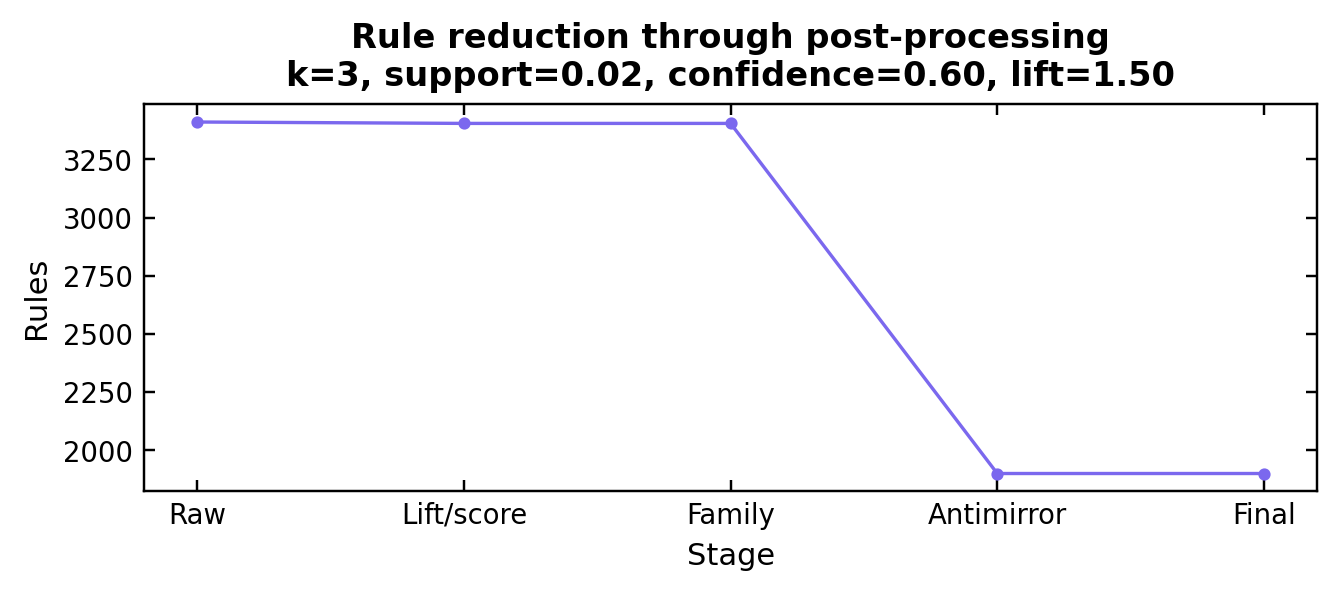

/Users/kevinkinsella/Documents/GitHub/In-Memory-Association-Rule-Mining-with-Hierarchical-Taxonomies/results/thesis_rebuilt_figures/fig07_rule_reduction_funnel.png


PosixPath('/Users/kevinkinsella/Documents/GitHub/In-Memory-Association-Rule-Mining-with-Hierarchical-Taxonomies/results/thesis_rebuilt_figures/fig07_rule_reduction_funnel.png')

In [7]:

# Figure 7: Rule reduction funnel, 100k sample, K=3.
k3 = cum[cum['k_levels'] == 3].iloc[0]
stages = ['Raw', 'Lift/score', 'Family', 'Antimirror', 'Final']
vals = [int(k3['raw_rules_median']), int(k3['score_rank_rules_median']), int(k3['family_dedupe_rules_median']), int(k3['final_rules_median']), int(k3['final_rules_median'])]
fig, ax = plt.subplots(figsize=(6.2, 2.8))
ax.plot(stages, vals, color='#7B68EE', marker='o', linewidth=1.1, markersize=3)
ax.set_ylabel('Rules')
ax.set_xlabel('Stage')
ax.set_title('Rule reduction through post-processing\nk=3, support=0.02, confidence=0.60, lift=1.50', fontweight='bold')
paper_axes(ax)
save_show(fig, 'fig07_rule_reduction_funnel.png')


## Figure 8

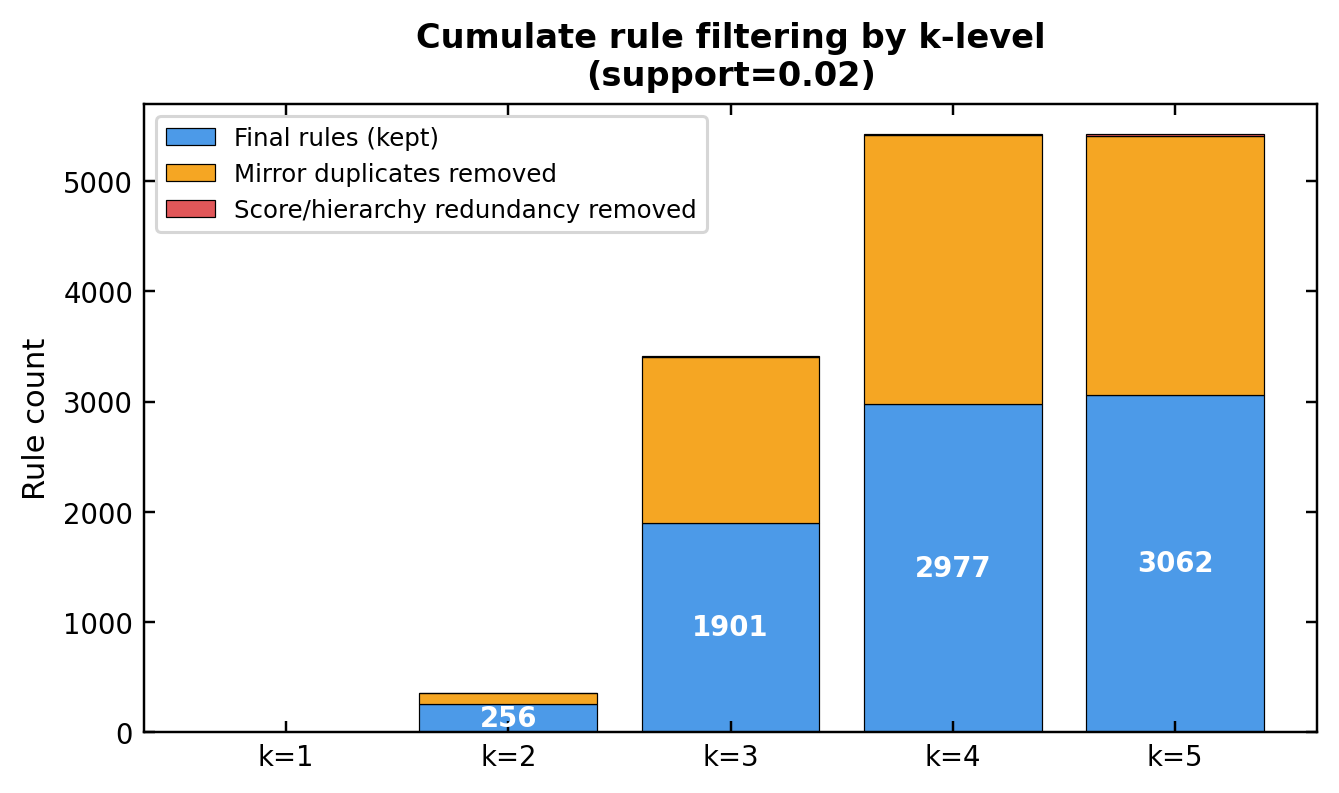

/Users/kevinkinsella/Documents/GitHub/In-Memory-Association-Rule-Mining-with-Hierarchical-Taxonomies/results/thesis_rebuilt_figures/fig08_thesis_redundancy_stacked.png


PosixPath('/Users/kevinkinsella/Documents/GitHub/In-Memory-Association-Rule-Mining-with-Hierarchical-Taxonomies/results/thesis_rebuilt_figures/fig08_thesis_redundancy_stacked.png')

In [8]:

# Figure 8: Stacked redundancy breakdown, 100k sample.
raw = cum['raw_rules_median'].fillna(0).astype(int).tolist()
score = cum['score_rank_rules_median'].fillna(0).astype(int).tolist()
family = cum['family_dedupe_rules_median'].fillna(0).astype(int).tolist()
final = cum['final_rules_median'].fillna(0).astype(int).tolist()
mirror_removed = [max(0, fml - fin) for fml, fin in zip(family, final)]
score_removed = [max(0, r - sc) for r, sc in zip(raw, score)]

fig, ax = plt.subplots(figsize=(6.2, 3.7))
x = np.arange(len(ks))
ax.bar(x, final, color='#4C9AE8', edgecolor='black', linewidth=0.4, label='Final rules (kept)')
ax.bar(x, mirror_removed, bottom=final, color=COL_ORANGE, edgecolor='black', linewidth=0.4, label='Mirror duplicates removed')
ax.bar(x, score_removed, bottom=np.array(final)+np.array(mirror_removed), color=COL_RED, edgecolor='black', linewidth=0.4, label='Score/hierarchy redundancy removed')
for xi, v in zip(x, final):
    if v > 100:
        ax.text(xi, v/2, f'{v}', color='white', ha='center', va='center', fontweight='bold', fontsize=9)
ax.set_xticks(x, [f'k={k}' for k in ks])
ax.set_ylabel('Rule count')
ax.set_title('Cumulate rule filtering by k-level\n(support=0.02)', fontweight='bold')
ax.legend(loc='upper left', frameon=True, fontsize=8)
paper_axes(ax)
save_show(fig, 'fig08_thesis_redundancy_stacked.png')


## Figure 9

In [ ]:

# Figure 9: Phase breakdown from old 100k phase benchmark.
# Show runtime_k rows for cpp/mlxtend/python across K.
phase_specs = [('apriori', 'apriori'), ('postprocess', 'post'), ('encode_transactions', 'encoding'), ('association_rules', 'rules'), ('build_transactions', 'transactions'), ('ancestor_map', 'ancestor')]
colors = {'apriori': COL_RED, 'post': '#8C564B', 'encoding': COL_ORANGE, 'rules': '#756BB1', 'transactions': COL_PY, 'ancestor': '#4CAF50'}
impl_order = [('cpp_cumulate', 'cpp'), ('mlxtend_flat', 'mlx'), ('python_cumulate', 'py')]
labels=[]; data={name:[] for _, name in phase_specs}
for k in ks:
    for impl, short in impl_order:
        sub = phase[(phase.experiment == 'runtime_k') & (phase.implementation == impl) & (phase.k_levels == k)]
        if sub.empty:
            continue
        labels.append(f'k{k}\n{short}')
        for phase_name, nice in phase_specs:
            val = sub.loc[sub.phase == phase_name, 'seconds_median']
            data[nice].append(float(val.iloc[0]) if len(val) and pd.notna(val.iloc[0]) else 0.0)
fig, ax = plt.subplots(figsize=(6.2, 3.52))
bottom = np.zeros(len(labels))
for _, nice in phase_specs:
    vals = np.array(data[nice])
    ax.bar(labels, vals, bottom=bottom, label=nice, color=colors[nice], edgecolor='black', linewidth=0.2)
    bottom += vals
ax.set_ylim(0, bottom.max() * 1.15)
ax.set_ylabel('seconds')
ax.set_title('Phase breakdown (support=0.02, confidence=0.6)', fontweight='bold')
ax.legend(ncol=3, loc='upper left', bbox_to_anchor=(0, 1), frameon=True, fontsize=7)
paper_axes(ax)
save_show(fig, 'fig09_phase_breakdown_baseline.png')


## Figures 10–12

## Figure 10

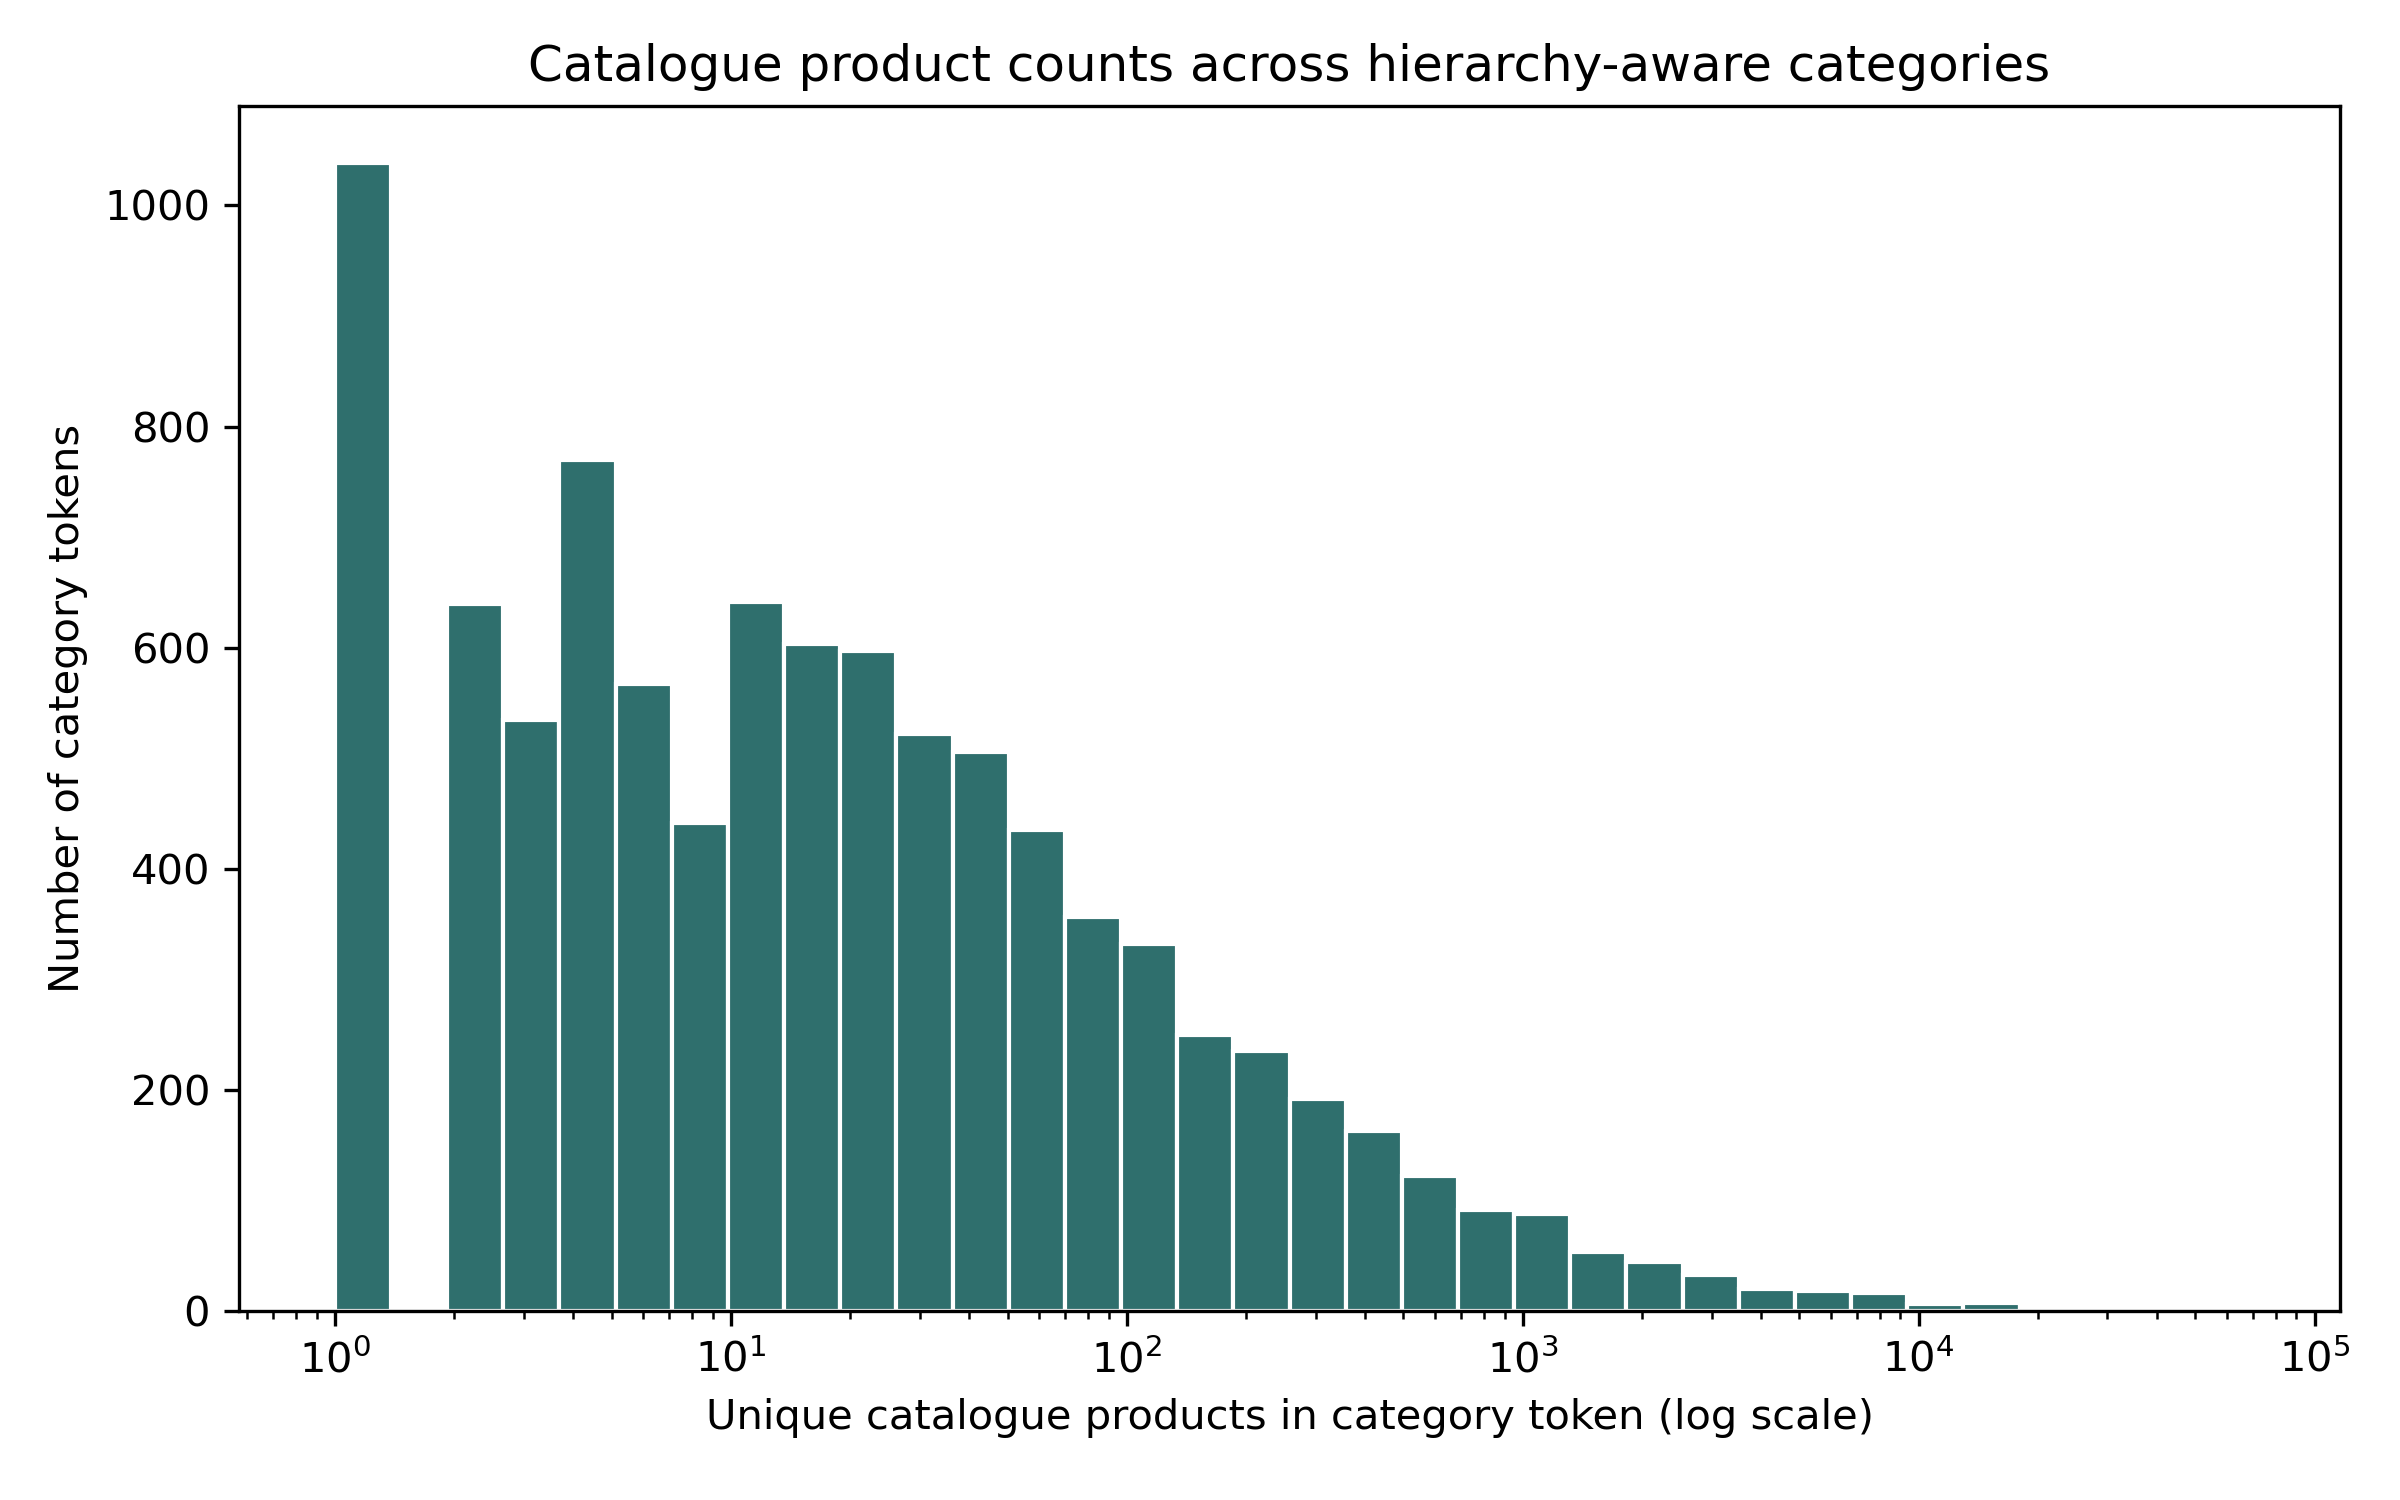

/Users/kevinkinsella/Documents/GitHub/In-Memory-Association-Rule-Mining-with-Hierarchical-Taxonomies/results/thesis_rebuilt_figures/fig10_category_inventory_histogram.png


## Figure 11

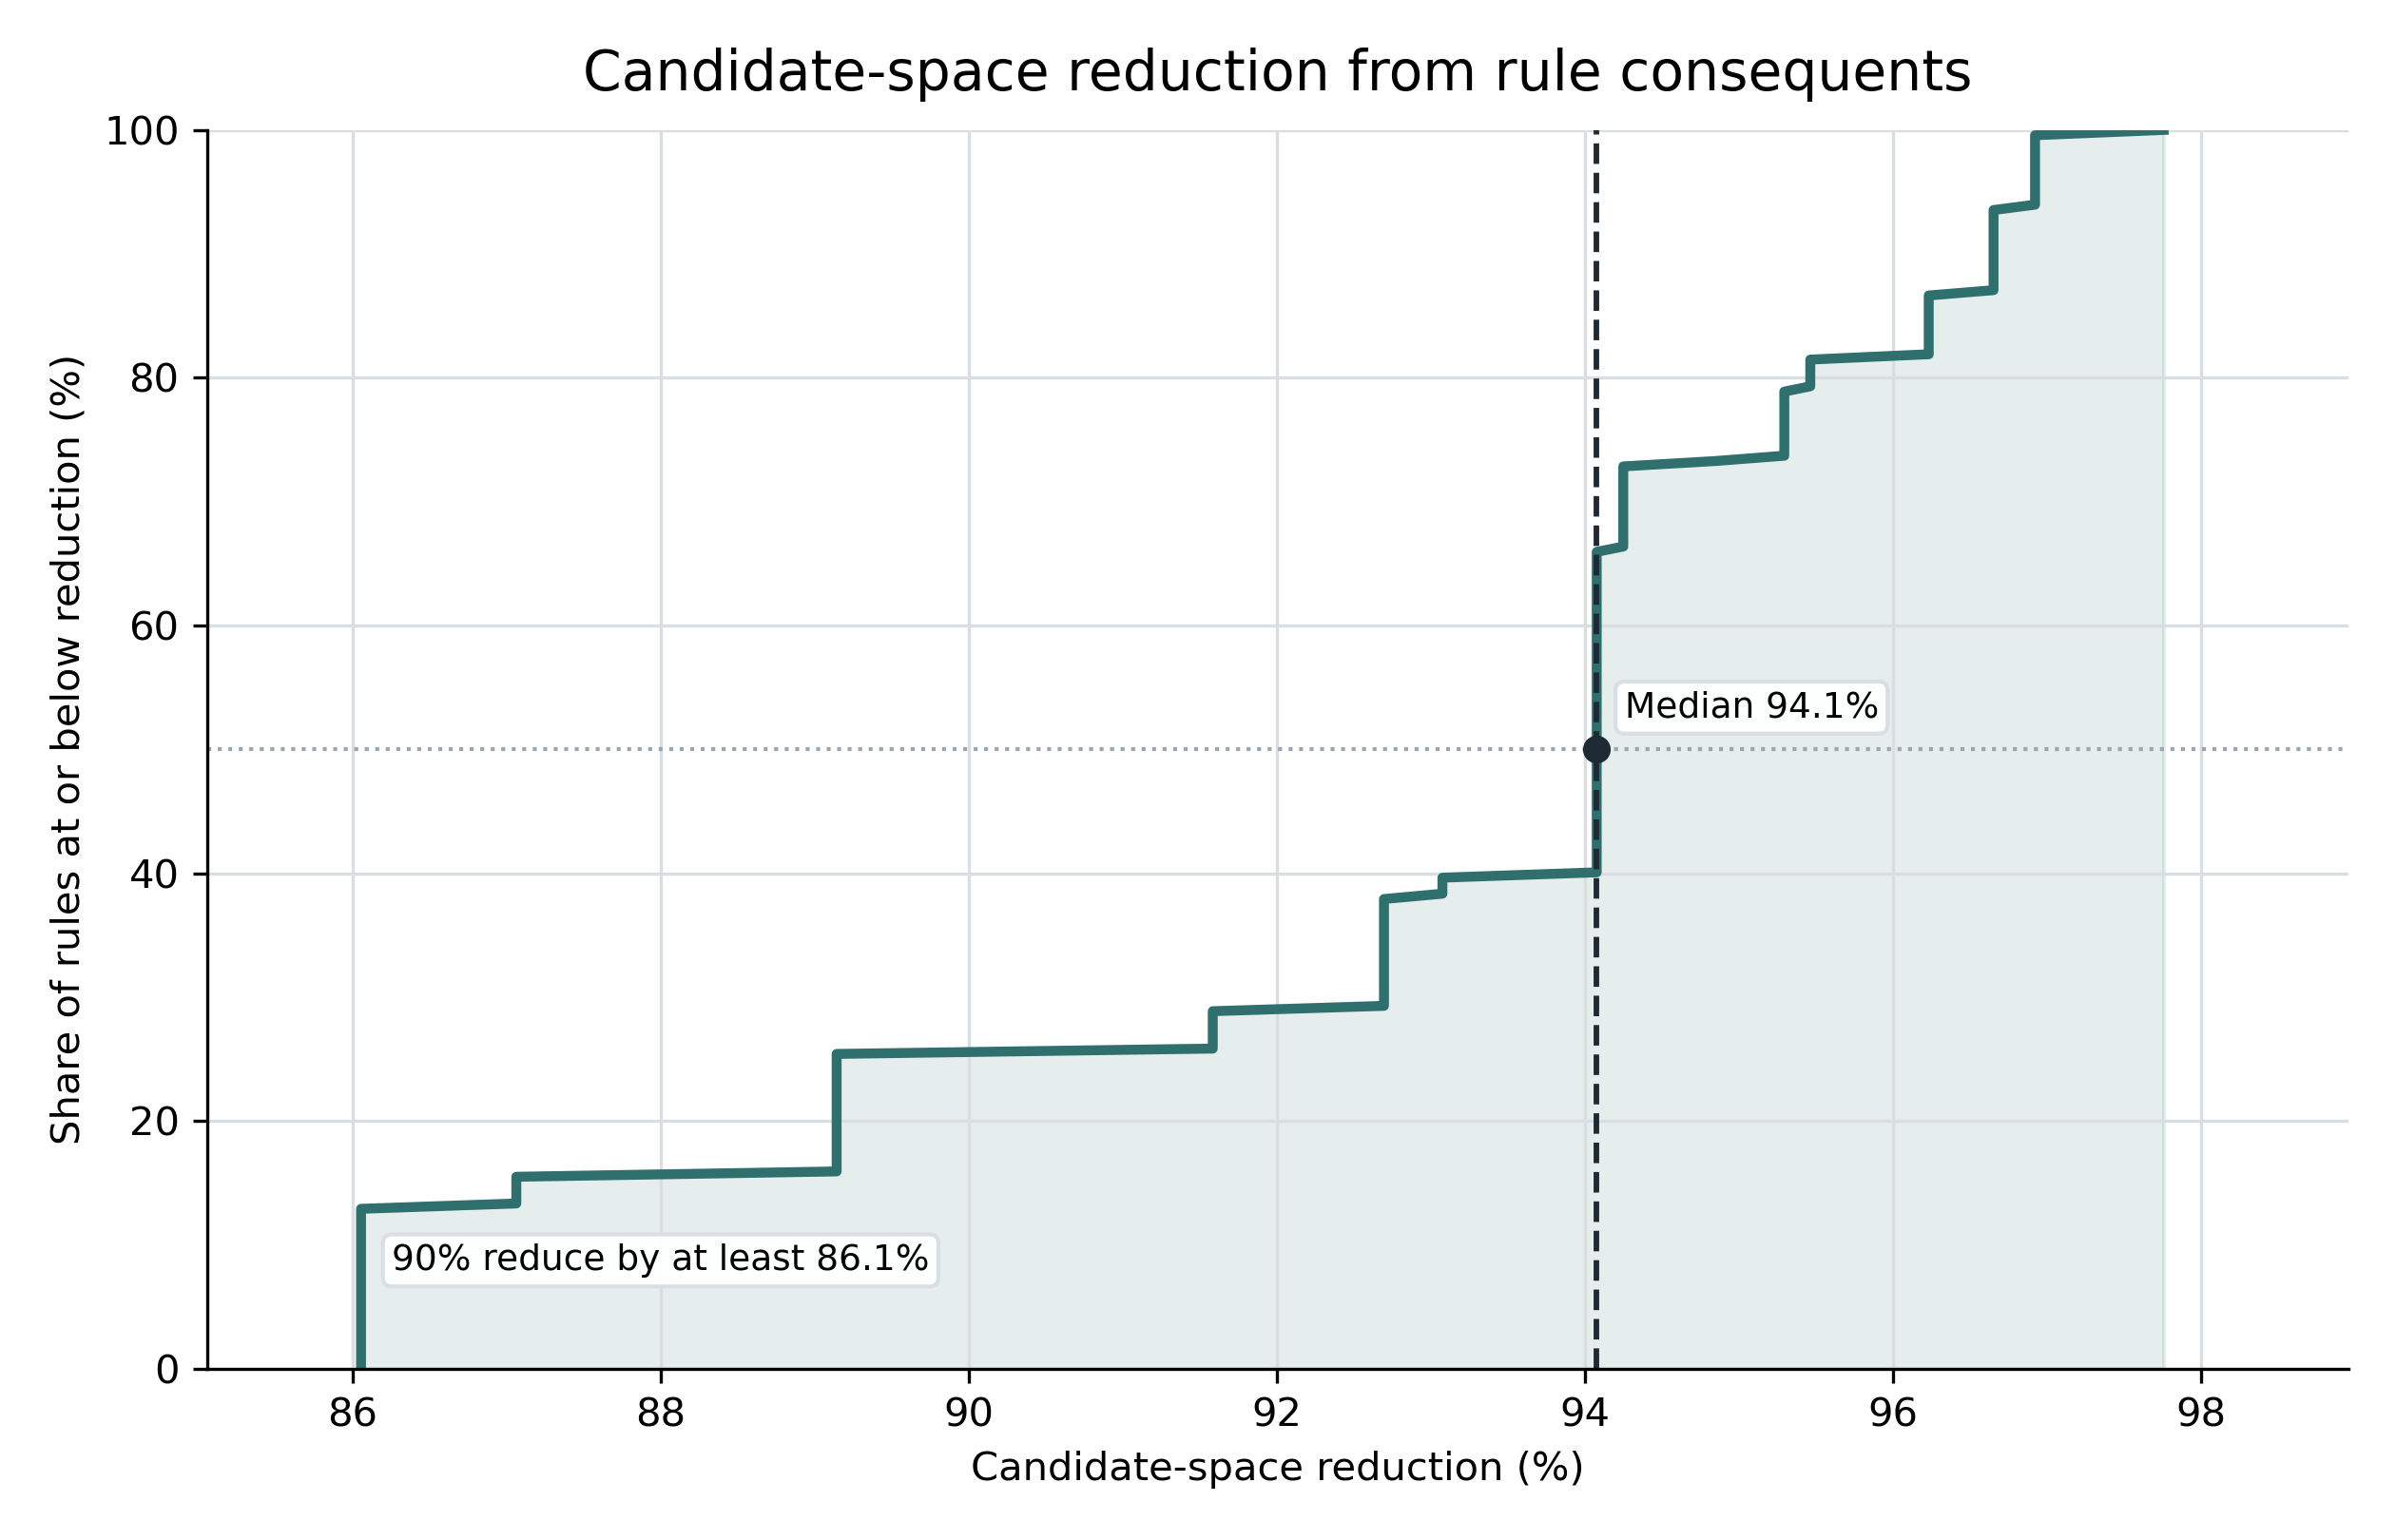

/Users/kevinkinsella/Documents/GitHub/In-Memory-Association-Rule-Mining-with-Hierarchical-Taxonomies/results/thesis_rebuilt_figures/fig11_candidate_space_reduction_from_rule_consequents.png


## Figure 12

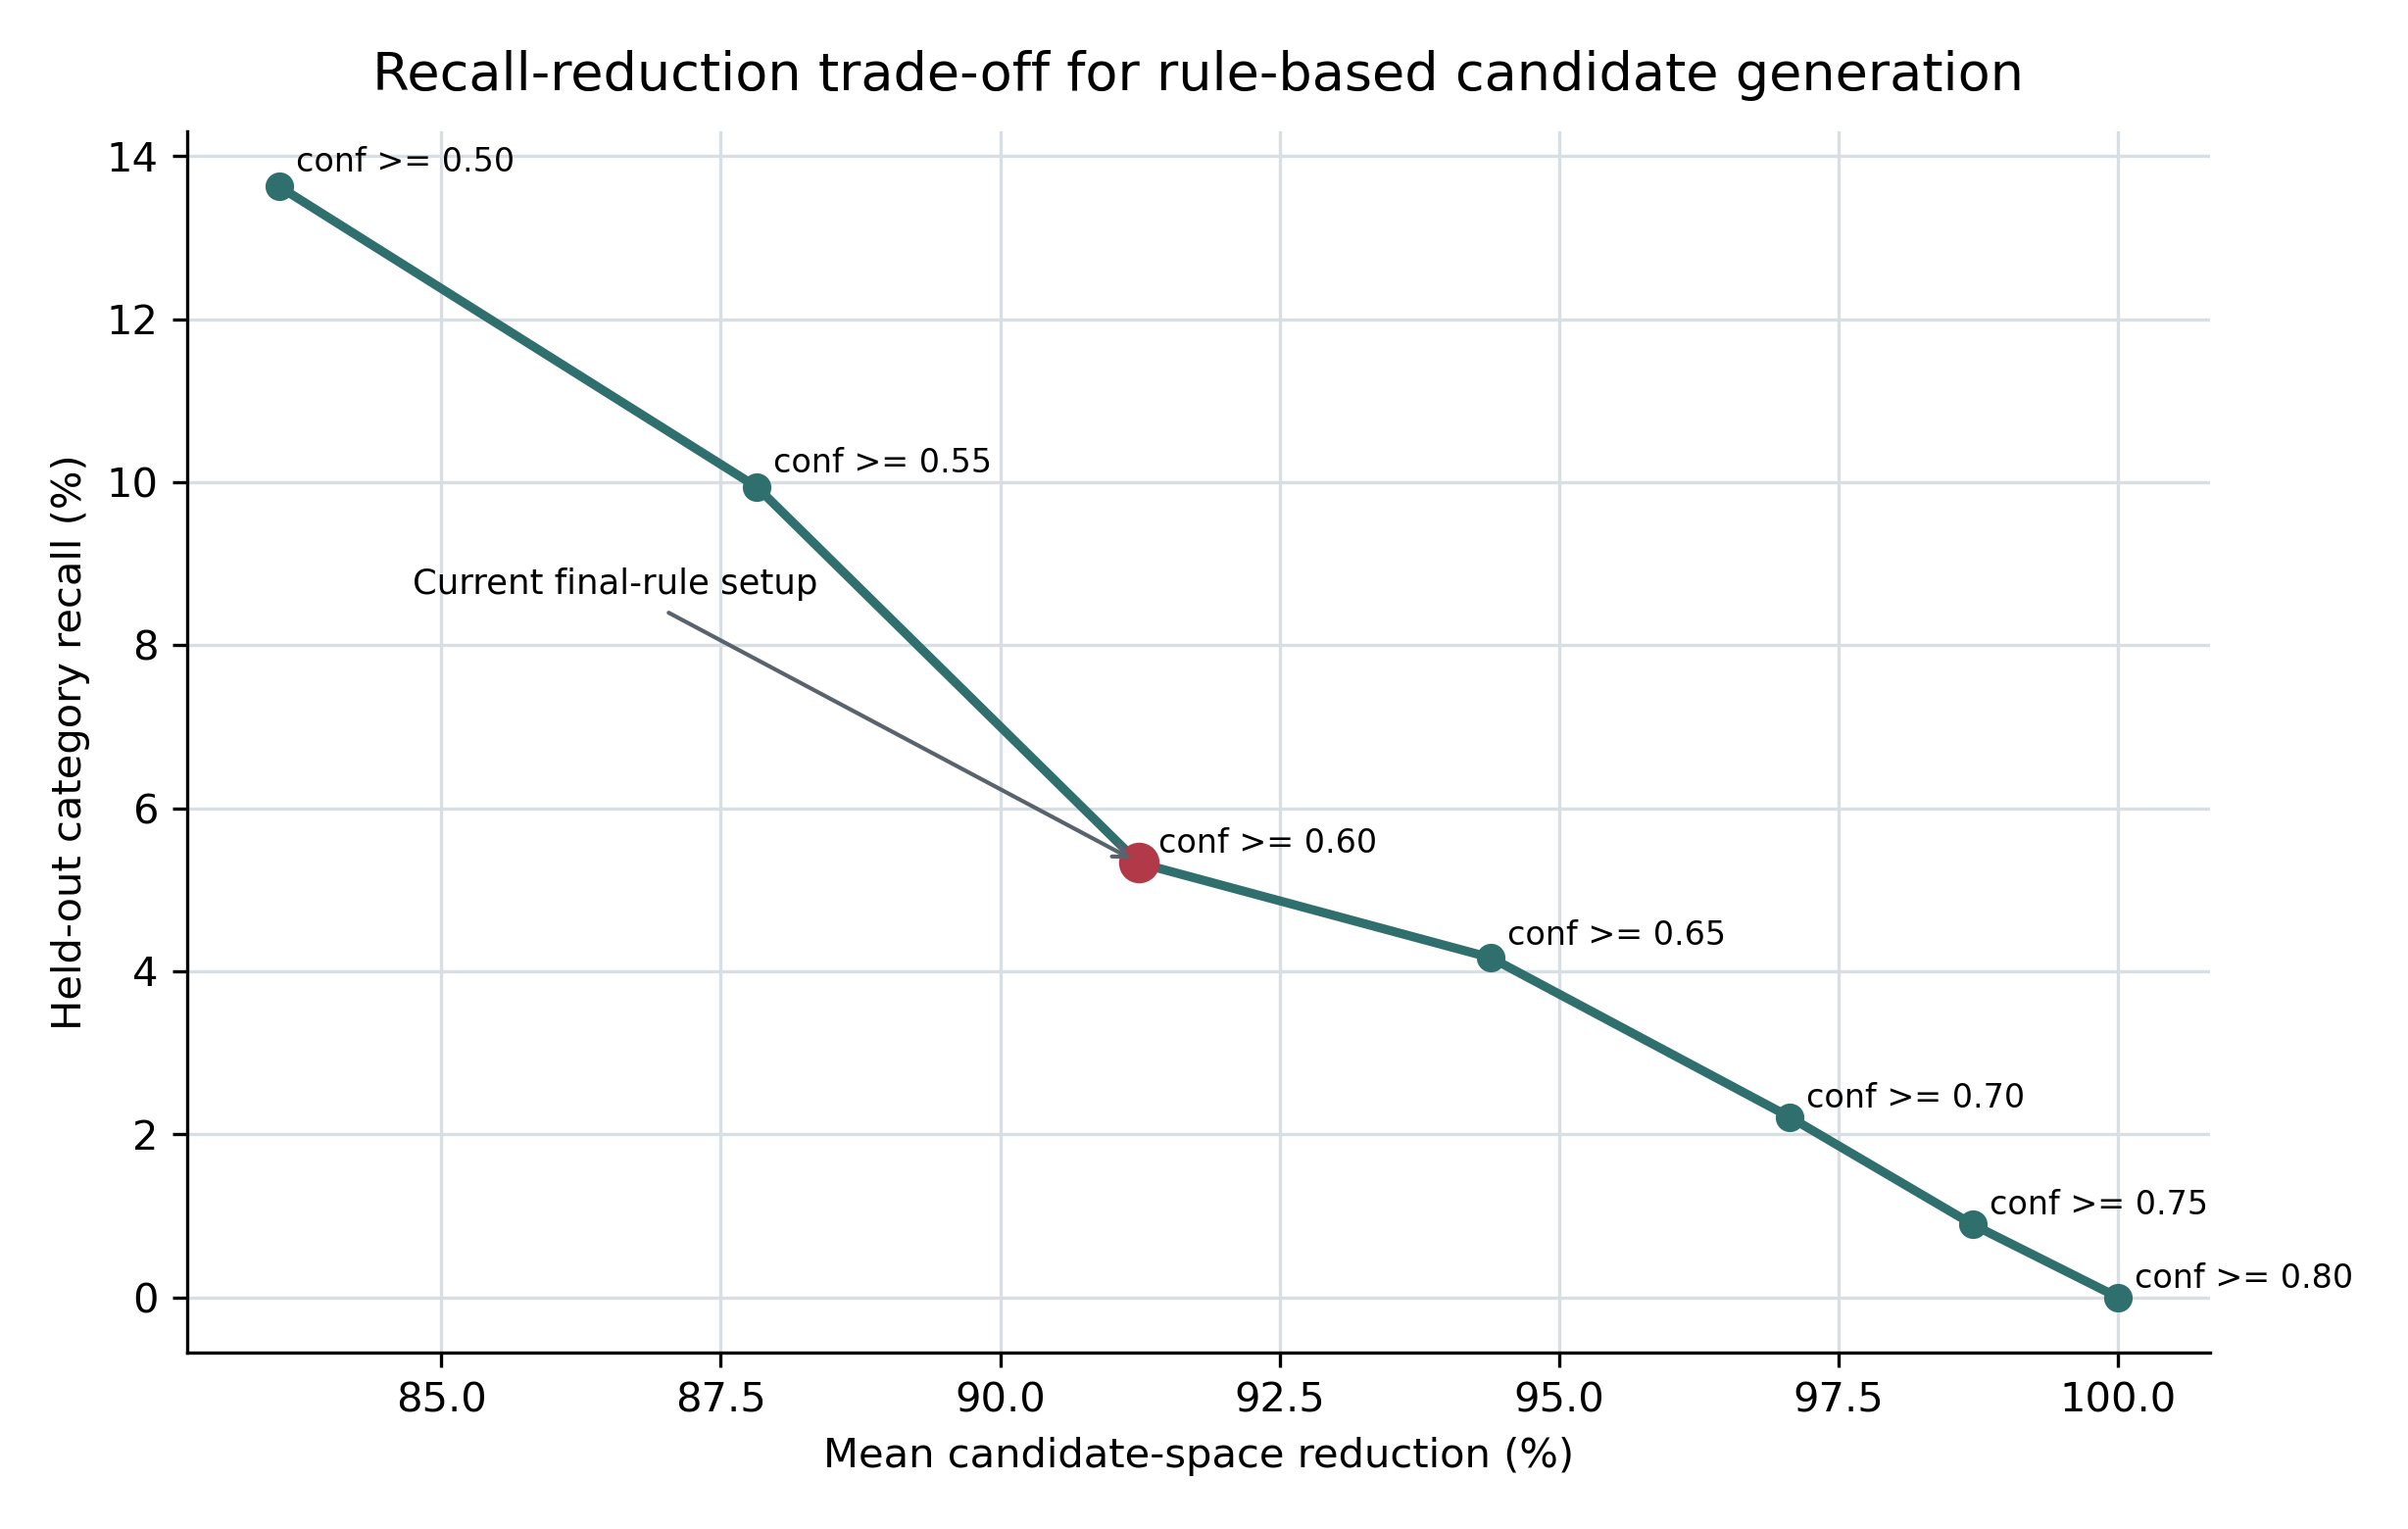

/Users/kevinkinsella/Documents/GitHub/In-Memory-Association-Rule-Mining-with-Hierarchical-Taxonomies/results/thesis_rebuilt_figures/fig12_recall_reduction_tradeoff.png


In [10]:

# Figures 10-12: these exact images come from the full-catalogue / held-out industrial benchmark.
for n, filename in [
    (10, 'category_inventory_histogram.png'),
    (11, 'candidate_space_reduction_from_rule_consequents.png'),
    (12, 'recall_reduction_tradeoff.png'),
]:
    display(Markdown(f'## Figure {n}'))
    show_existing(INDUSTRIAL / filename, f'fig{n:02d}_{filename}')


## Sanity Checks

In [11]:

# Sanity checks: these should match the thesis narrative.
print('Figure 2/3 final rules by K:', dict(zip(ks, finals)))
print('Figure 3 mlxtend rules by K:', dict(zip(ks, mlx_rules)))
print('Figure 4 K=1 times: Python=', runtime_k.loc[0, 'python_cumulate'], 'mlxtend=', runtime_k.loc[0, 'mlxtend_flat'], 'C++=', runtime_k.loc[0, 'cpp_cumulate'])
print('Python faster than mlxtend at K=1:', runtime_k.loc[0, 'python_cumulate'] < runtime_k.loc[0, 'mlxtend_flat'])
print('Candidate summary:')
display(pd.read_csv(INDUSTRIAL / 'candidate_reduction_summary.csv'))
print('Recall/reduction tradeoff:')
display(pd.read_csv(INDUSTRIAL / 'recall_reduction_tradeoff.csv'))


Figure 2/3 final rules by K: {1: 2, 2: 256, 3: 1901, 4: 2977, 5: 3062}
Figure 3 mlxtend rules by K: {1: 2, 2: 2, 3: 2, 4: 2, 5: 2}
Figure 4 K=1 times: Python= 0.77 mlxtend= 1.345 C++= 0.024
Python faster than mlxtend at K=1: True
Candidate summary:


,Catalogue size,Final rules,Single-consequent rules,Median candidate products,Median remaining share (%),Median reduction (%),P25 reduction (%),P75 reduction (%)
0,476455,232,232,28215.0,5.92186,94.07814,89.143361,95.295883


Recall/reduction tradeoff:


,confidence_threshold,rules,candidate_share_pct,reduction_pct,held_out_recall_pct
0,0.50,535,16.451125,83.548875,13.625482
1,0.55,437,12.176139,87.823861,9.938172
2,0.60,330,8.760409,91.239591,5.328603
3,0.65,222,5.608028,94.391972,4.164370
4,0.70,93,2.936424,97.063576,2.211353
5,0.75,20,1.297528,98.702472,0.891258
6,0.80,0,0.000000,100.000000,0.000000
